In [1]:
import pandas as pd
from Bio.SeqIO.FastaIO import SimpleFastaParser as sfp
import matplotlib.pyplot as plt
from collections import defaultdict
from bs4 import BeautifulSoup
import seaborn as sns
import pysam, os, glob, skbio, math, random, time
from scipy import stats
from Bio import Entrez
Entrez.email = "ajaffe@stanford.edu"

In [2]:
def cmdir(path):
    if not os.path.isdir(path):
        os.mkdir(path)
        
def datestamp():
    return date.today().strftime("%Y-%m-%d")

def sbatch(name, cpus, cmd):
    return "sbatch -J %s -p serc -t 1- -c %d --mem %dG --wrap '%s'" %(name, cpus, cpus*8, cmd)

In [3]:
rootdir = "/scratch/users/ajaffe/ocdata/"
cmdir(rootdir + "sra")

### prelim

In [4]:
#oc17
internal = pd.read_csv(rootdir + "tables/deepeco_supp_tables_s1.tsv", sep="\t")
internal = internal[["bioproject", "biosample", "reported", "sample_name",
                     "depth_m", "latitude", "longitude", "reads_gbp"]].rename(columns={"reported": "reference"})
internal["dataset_final"] = "OC1703A Transect"
internal.head()

,bioproject,biosample,reference,sample_name,depth_m,latitude,longitude,reads_gbp,dataset_final
0,PRJNA1054206,SAMN40577035,Jaffe et al. 2024 (this study),OC2_50m,50,37.036683,-122.70133,41.94,OC1703A Transect
1,PRJNA1054206,SAMN40577036,Jaffe et al. 2024 (this study),OC2_150m,150,37.036683,-122.70133,44.30,OC1703A Transect
2,PRJNA1054206,SAMN40577037,Jaffe et al. 2024 (this study),OC2_500m,500,37.036683,-122.70133,41.42,OC1703A Transect
3,PRJNA1054206,SAMN38912613,Arandia-Gorostidi et al. in rev.,OC3_50m,50,36.799083,-122.97433,55.73,OC1703A Transect
4,PRJNA1054206,SAMN38912614,Arandia-Gorostidi et al. in rev.,OC3_150m,150,36.799083,-122.97433,62.07,OC1703A Transect


In [5]:
# public - make long format
external = pd.read_csv(rootdir + "tables/deepeco_supp_tables_s10.tsv", sep="\t").fillna("None")

ext = defaultdict(list)

for key, row in external.iterrows():
    if row["run_accession"] != 'None':
        for item in row["run_accession"].split(","):
            ext["run"].append(item)
            for field in ["sample", "dataset", "latitude", 
                          "longitude", "depth"]:
                ext[field].append(row[field])

extdf = pd.DataFrame(ext)
extdf.head()

,run,sample,dataset,latitude,longitude,depth
0,SRR5788347,BGEO_SAMN07136678_METAG,Biogeotraces,-49.54750,-52.68850,10
1,SRR5788350,BGEO_SAMN07136679_METAG,Biogeotraces,-49.54750,-52.68850,49
2,SRR5788089,BGEO_SAMN07136591_METAG,Biogeotraces,39.69225,-69.86286,30
3,SRR5788090,BGEO_SAMN07136592_METAG,Biogeotraces,39.69225,-69.86286,57
4,SRR5788221,BGEO_SAMN07136593_METAG,Biogeotraces,39.69225,-69.86286,89


### use run selector

"marine metagenome"[Organism] OR "seawater metagenome"[Organism] NOT benthic NOT sediment NOT symbiont NOT "coral holobiont" NOT amplicon[Strategy] NOT "rna seq"[Strategy] AND metagenomic[Source]

In [6]:
runinfo = pd.read_csv(rootdir + "tables/SRARunTable_12092025.csv", dtype='str').fillna("None")

In [7]:
runinfo = runinfo[(~runinfo["Depth"].str.contains("cm")) & 
                  (~runinfo["Depth"].str.contains("mbsf")) &
                  (runinfo["Bases"]!='None')]

runinfo["reads_gbp"] = runinfo["Bases"].apply(lambda x: int(x)/1e9)

In [8]:
import numpy as np
import re

def any_numeric(value):
    
    flag = False
    for char in value:
         if char.isnumeric() == True:
            flag = True
    return flag

def clean_up_depth(value):
    
    stripped = value.replace(" ","").replace("m","")
    
    if (re.search("[A-z]*([0-9\.-]+).*", stripped)) and (any_numeric(stripped) == True):
        
        extracted = re.search("[A-z]*([0-9\.-]+).*", stripped).group(1)
        
        if extracted.startswith("-"):
            numerical = float(extracted.replace("-",""))
       
        elif "-" in extracted:
            first = float(extracted.split("-")[0])
            second = float(extracted.split("-")[1])
            numerical = np.mean([first, second])
        
        else: numerical = float(extracted)

        return numerical
    
    else: return "None"

runinfo["depth_curated"] = runinfo["Depth"].apply(clean_up_depth)

In [9]:
datasets = {row["run"]: row["dataset"] for 
            key, row in extdf.query("dataset!='Indian Ocean Transect'").iterrows()}

def assign_project(row):
    
    if row["Run"] in datasets:
        return datasets[row["Run"]]
    elif "Tara" in row["project_name"]:
        return "Tara Oceans"
    elif "Malaspina" in row["project_name"]:
        return "Malaspina"
    elif row["BioProject"] in ["PRJNA16339", "PRJNA301051"]:
        return "Hawaii Ocean Timeseries"
    else: return "Other"
    
runinfo["project_name_curated"] = runinfo.apply(assign_project, axis=1)

### repair missing metadata

In [10]:
fixes = {}
ds_fixes = {}
drop = ["PRJEB50838", "PRJNA1077797", "PRJNA1093391", "PRJNA847179", "PRJNA450643",
        "PRJNA329908", "PRJNA556155", "PRJNA978314", "PRJEB34035", "PRJNA819259",
       "PRJNA1056564", "PRJNA1004747", "PRJNA982185", "PRJNA395437", "PRJNA639602",
       "PRJEB48301", "PRJNA649049", "PRJEB48192", "PRJNA895529", "PRJNA318384", "PRJNA756323",
       "PRJNA301966", "PRJEB49194", "PRJNA435478", "PRJEB9136", "PRJNA981336", "PRJNA606180", 
        "PRJNA551656", "PRJEB60262", "PRJNA693108", "PRJNA207724", "PRJNA1054206", "PRJDB37029",
       "PRJNA1227591","PRJNA558921", "PRJNA1244327", "PRJNA1244326", "PRJNA1244328"]
drop_accs = []

for key, row in pd.read_csv(rootdir + "tables/PRJNA656268.csv").iterrows():
    fixes[row["SRA Accession Number"]] = row["Depth [m]"]

for key, row in runinfo.query("BioProject=='PRJNA1081583'").iterrows():
    fixes[row["Run"]] = row["samp_collect_device"].split("\\,")[1].strip().replace("m depth", "")
    
for key, row in pd.read_csv(rootdir + "tables/PRJNA326482.csv").iterrows():
    fixes[row["ncbi_metagenome_name"]] = row["depth"]

for key, row in pd.read_csv(rootdir + "tables/PRJNA247822.csv").fillna("None").iterrows():
    fixes[row["MetaG BioSample Accession"]] = row["Depth (m)"]
    
for key, row in pd.read_csv(rootdir + "tables/PRJNA588686.csv").fillna("None").iterrows():
    for exp in row["Experiment"].split(","):
        fixes[exp] = row["Depth (m)"]

for key, row in runinfo.query("BioProject=='PRJNA588686'").iterrows():
    ds_fixes[row["Run"]] = "PM-RGC"
        
for key, row in runinfo.query("BioProject=='PRJEB4352'").query("depth_curated=='None'").iterrows():
    
    if "SUR" in row["Sample_name"]:
        fixes[row["Run"]] = 5
    elif "23DCM" in row["Sample_name"]:
        fixes[row["Run"]] = 55
    elif "30DCM" in row["Sample_name"]:
        fixes[row["Run"]] = 70
    elif "7DCM" in row["Sample_name"]:
        fixes[row["Run"]] = 42
        
for key, row in runinfo.query("BioProject=='PRJNA704804'").iterrows():
    
    if "Metagenome" in row["Sample Name"]:
        fixes[row["Run"]] = row["Sample Name"].split(" ")[2].replace("m","")
    else: fixes[row["Run"]] = row["Sample Name"].split("_")[0].replace("m","")
        
for key, row in pd.read_csv(rootdir + "tables/PRJNA1031568.csv").iterrows():
    fixes[row["Sample IDs"] + "_metagenome"] = row["Depth\n(m)"]
    
for key, row in runinfo.query("BioProject=='PRJNA1003508'").iterrows():
    fixes[row["Run"]] = row["Sample Name"].split(" ")[2].strip("m")
    
for key, row in runinfo.query("BioProject=='PRJNA748533'").iterrows():
    if ("SW13" in row["Sample Name"]) or ("SW12" in row["Sample Name"]):
        fixes[row["Run"]] = row["Sample Name"].split("-")[-1]
    else: fixes[row["Run"]] = 5
        
for key, row in pd.read_csv(rootdir + "tables/PRJEB41592.csv").iterrows():
    fixes[row["ENA_Sample_accession_number"]] = row["Depth (m)"]
    
for key, row in runinfo.query("BioProject=='PRJEB9691'").query("depth_curated=='None'").iterrows():
    fixes[row["Run"]] = 5 # based on SUR in Sample_name
    
for key, row in runinfo.query("BioProject=='PRJEB31948'").query("depth_curated=='None'").iterrows():
    fixes[row["Run"]] = int(row["Sample_name"][-3:])
    
for key, row in runinfo.query("BioProject=='PRJNA605648'").query("depth_curated=='None'").iterrows():
    fixes[row["Run"]] = row["isolation_source"].split(" ")[-1].strip("m")
    
for key, row in runinfo.query("BioProject=='PRJNA544741'").query("depth_curated=='None'").iterrows():
    fixes[row["Run"]] = row["Sample Name"][-3:]
    
for key, row in runinfo.query("BioProject=='PRJNA724894'").query("depth_curated=='None'").iterrows():
    if "DCM" not in row["Library Name"]:
        fixes[row["Run"]] = row["Library Name"].split("-")[2].strip("_meta")

for key, row in runinfo.query("BioProject=='PRJNA412741'").query("depth_curated=='None'").iterrows():
    fixes[row["Run"]] = row["Sample Name"].strip("F").strip("P")
    
for key, row in runinfo.query("BioProject=='PRJNA535364'").query("depth_curated=='None'").iterrows():
    fixes[row["Run"]] = row["Sample Name"].split("_")[1]
    
for key, row in runinfo.query("BioProject=='PRJNA428417'").query("depth_curated=='None'").iterrows():
    if "sw" in row["Library Name"]:
        fixes[row["Run"]] = 0
    elif "HS5bw" in row["Library Name"]:
        fixes[row["Run"]] = 30
    elif "H12bw" in row["Library Name"]:
        fixes[row["Run"]] = 60
        
for key, row in runinfo.query("BioProject=='PRJNA541485'").query("depth_curated=='None'").iterrows():
    fixes[row["Run"]] = row["Sample Name"].split("-")[0].strip("F").strip("P")
    
for key, row in runinfo.query("BioProject=='PRJNA1196485'").iterrows():
    fixes[row["Run"]] = int(row["Sample Name"].split("_")[-1].replace("m",""))
    ds_fixes[row["Run"]] = "GO-SHIP P18"
    
for key, row in runinfo.query("BioProject=='PRJEB74659'").iterrows():
    raw_depth = row["Sample Name"].split("_")[-1]
    if "-" in raw_depth:
        first = float(raw_depth.split("-")[0])
        second = float(raw_depth.split("-")[1])
        fixes[row["Run"]] = np.mean([first, second])
    elif raw_depth.isnumeric(): 
        fixes[row["Run"]] = int(raw_depth)
    else: continue
        
for key, row in runinfo.query("BioProject=='PRJNA1063027'").iterrows():
    fixes[row["Run"]] = 1

for key, row in runinfo.query("BioProject=='PRJNA911943'").iterrows():
    ds_fixes[row["Run"]] = "Bermuda Atlantic Time Series"
    
for key, row in runinfo.query("BioProject=='PRJNA1173117'").iterrows():
    raw_depth = row["Sample Name"].split("-")[1]
    if raw_depth.isnumeric():
        fixes[row["Run"]] = int(raw_depth)
        
for key, row in runinfo.query("BioProject=='PRJNA1109759'").iterrows():
    fixes[row["Run"]] = 1038
    
for key, row in runinfo.query("BioProject=='PRJEB75506'").iterrows():
    ds_fixes[row["Run"]] = "GEOTRACES"

#only keep T0s
for key, row in runinfo.query("BioProject=='PRJNA1069756'").iterrows():
    if ("T0" not in row["Sample Name"]) or ("BONCAT" in row["Sample Name"]):
        drop_accs.append(row["Run"])
    
for key, row in pd.read_csv(rootdir + "tables/sra_slush.tsv", sep="\t").fillna("None").iterrows():
    fixes[row["run"]] = row["depth"]
    
    if row["dataset"]!='None':
        ds_fixes[row["run"]] = row["dataset"]

In [11]:
def repair(row):
    
    depth = 'None'
    for column in runinfo:
        if row[column] in fixes:
            depth = fixes[row[column]]
            break
    return float(depth) if depth != 'None' else depth

def reconcile(row):
    
    if row["depth_curated"] != 'None':
        return row["depth_curated"]
    elif row["depth_manual"] != 'None':
        return row["depth_manual"]
    else: return 'None'
        
runinfo["depth_manual"] = runinfo.apply(lambda x: repair(x), axis=1)
runinfo["depth_final"] = runinfo.apply(lambda x: reconcile(x), axis=1)

### plot out

In [12]:
subset = runinfo[["Run", "BioProject", "BioSample", "project_name_curated", "depth_final", "reads_gbp"]]
subset = subset.query("depth_final!='None'").rename(columns={"BioProject": "bioproject", "BioSample":"biosample",
                                                              "project_name_curated":"dataset", "depth_final":"depth"})
subset.head()

,Run,bioproject,biosample,dataset,depth,reads_gbp
0,SRR16949433,PRJNA779973,SAMN23097565,Other,0.1,3.950352
1,SRR16949434,PRJNA779973,SAMN23097564,Other,0.1,4.599151
2,SRR16949436,PRJNA779973,SAMN23097562,Other,0.1,3.066090
3,SRR16949437,PRJNA779973,SAMN23097561,Other,0.1,2.885696
4,SRR16949438,PRJNA779973,SAMN23097560,Other,0.1,2.961168


In [13]:
#amend dataset
subset["dataset_manual"] = subset["Run"].map(ds_fixes).fillna("None")
subset["dataset_final"] = subset.apply(lambda x: x["dataset_manual"] if \
                                       x["dataset_manual"]!='None' else x["dataset"], axis=1)
# remove drops
subset = subset[(~subset["Run"].isin(drop_accs)) & (~subset["bioproject"].isin(drop))]
subset["dataset_final"].value_counts()

Other                           12052
Tara Oceans                      1666
Biogeotraces                      460
Malaspina                         383
GO-SHIP P18                       160
PM-RGC                            120
GEOTRACES                          69
Hawaii Ocean Timeseries            58
OMZ                                18
Malaspina viral                    14
Bermuda Atlantic Time Series        6
Name: dataset_final, dtype: int64

In [14]:
merged = pd.concat([internal.drop(["reference", "sample_name", "latitude", 
                                   "longitude"], axis=1).rename(columns={"depth_m": "depth"}),subset]).fillna("None")
merged["depth_negative"] = merged["depth"].apply(lambda x: x*-1)

gp = merged.query("reads_gbp!='None'").groupby(["dataset_final", 
    "depth_negative"], as_index=False).aggregate({"reads_gbp":"sum"})

aggregate_info = defaultdict(list)

for key, row in gp.iterrows():
    
    num = int(round(row["reads_gbp"],0))

    for i in range(0,num):
        aggregate_info["dataset"].append(row["dataset_final"])
        aggregate_info["depth_negative"].append(row["depth_negative"])

aggregate_df = pd.DataFrame(aggregate_info)

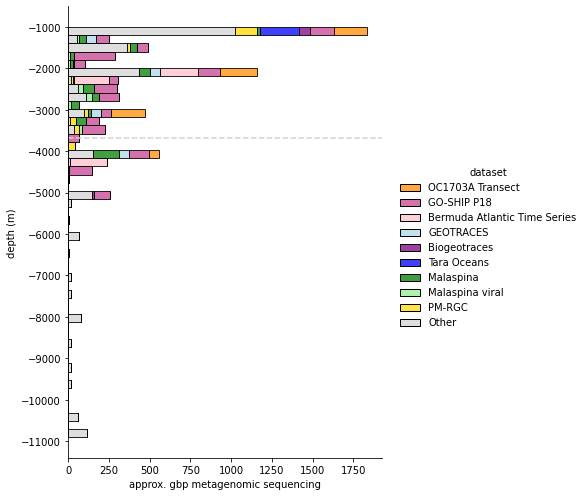

In [15]:
palette = {"Other":"lightgrey", "OC1703A Transect": "darkorange", "Biogeotraces":"purple",
          "Tara Oceans":"blue", "Malaspina": "green",  "Malaspina viral": "lightgreen", "PM-RGC":"gold",
           "GEOTRACES":"lightblue", "Bermuda Atlantic Time Series": "pink", "GO-SHIP P18":"#C74290"}
order = ["OC1703A Transect", "GO-SHIP P18", "Bermuda Atlantic Time Series", "GEOTRACES", "Biogeotraces", 
         "Tara Oceans", "Malaspina", "Malaspina viral", "PM-RGC","Other"]
sns.displot(data=aggregate_df.query("depth_negative<=-1000").query("depth_negative!=-99999"),
            y="depth_negative", hue="dataset", palette=palette, hue_order=order,
            bins=50,multiple="stack", height=7, aspect=0.8)
plt.axhline(-3682, c="lightgrey", linestyle="--")
plt.yticks([i for i in range(-1000,-12000,-1000)])
plt.ylabel("depth (m)")
plt.xlabel("approx. gbp metagenomic sequencing")
plt.savefig(rootdir + "figures/sequencing_effort_1000m.svg", format="svg")
plt.show()

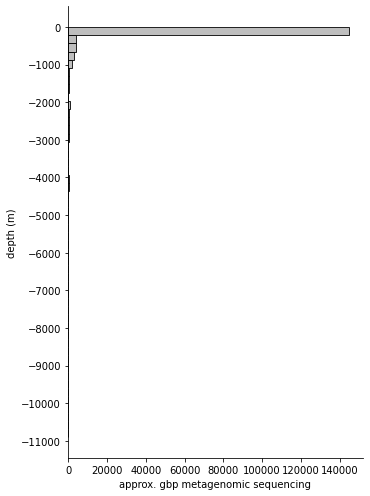

In [16]:
sns.displot(data=aggregate_df.query("depth_negative!=-99999"),
            y="depth_negative",color='darkgrey',
            bins=50,multiple="stack", height=7, aspect=0.75)
plt.yticks([i for i in range(-0,-12000,-1000)])
plt.ylabel("depth (m)")
plt.xlabel("approx. gbp metagenomic sequencing")
plt.savefig(rootdir + "figures/sequencing_effort_full.svg", format="svg")
plt.show()

In [17]:
len(aggregate_df.query("depth_negative<=-1000").query("dataset=='OC1703A Transect'"))/len(aggregate_df.query("depth_negative<=-1000"))

0.08978805394990366

### write out supp table

In [97]:
oc_runtable = pd.read_csv(rootdir + "tables/OC1703A_RunTable.csv")
oc_lookup = {row["BioSample"]:row["Run"] for key, row in oc_runtable.iterrows()}

merged["run"] = merged.apply(lambda x: oc_lookup[x["biosample"]] if x["biosample"] in oc_lookup else x["Run"], axis=1)
base = merged[["bioproject", "dataset_final", "biosample", "run", "depth", "reads_gbp"]].rename(columns={"dataset_final":"dataset"})
base = base.query("depth>=1000")

In [98]:
# add in contextual data for other projects
bp_info = defaultdict(list)

for bioproject in base["bioproject"].unique():
    
    try:
        
        handle = Entrez.efetch(db="bioproject", id=bioproject)
        soup = BeautifulSoup(handle, "lxml")
        handle.close()
        title = soup.find("title").string
        
    except:
        title = "None"
    
    bp_info["bioproject"].append(bioproject)
    bp_info["bioproject_title"].append(title)
    
    time.sleep(0.25)
    
bp_df = pd.DataFrame(bp_info)
bp_df.head()

/home/users/ajaffe/.local/lib/python3.6/site-packages/bs4/builder/__init__.py:546: XMLParsedAsHTMLWarning: It looks like you're parsing an XML document using an HTML parser. If this really is an HTML document (maybe it's XHTML?), you can ignore or filter this warning. If it's XML, you should know that using an XML parser will be more reliable. To parse this document as XML, make sure you have the lxml package installed, and pass the keyword argument `features="xml"` into the BeautifulSoup constructor.
  XMLParsedAsHTMLWarning.MESSAGE, XMLParsedAsHTMLWarning


,bioproject,bioproject_title
0,PRJNA1054206,"Microbial communities from the epipelagic, mes..."
1,PRJNA681031,Arctic Metagenomes
2,PRJNA727670,Exocellular DNA in the North Pacific Subtropic...
3,PRJNA748533,the microbes of South China Sea
4,PRJNA746083,marine metagenome Metagenome


In [78]:
bp_df.query("bioproject_title=='None'").to_csv(rootdir + "tables/bioproject_curation.tsv", sep="\t", index=False)

In [99]:
bp_curated = pd.read_csv(rootdir + "tables/bioproject_curated.tsv", sep="\t")
bp_df = bp_df.merge(bp_curated[["bioproject", "manual"]], how="left", on="bioproject")
bp_df["bioproject_final"] = bp_df.apply(lambda x: x["manual"] if x["bioproject_title"] == "None" else x["bioproject_title"], axis=1)
bp_df.head()

,bioproject,bioproject_title,manual,bioproject_final
0,PRJNA1054206,"Microbial communities from the epipelagic, mes...",NaN,"Microbial communities from the epipelagic, mes..."
1,PRJNA681031,Arctic Metagenomes,NaN,Arctic Metagenomes
2,PRJNA727670,Exocellular DNA in the North Pacific Subtropic...,NaN,Exocellular DNA in the North Pacific Subtropic...
3,PRJNA748533,the microbes of South China Sea,NaN,the microbes of South China Sea
4,PRJNA746083,marine metagenome Metagenome,NaN,marine metagenome Metagenome


In [104]:
base = base.merge(bp_df, how="left")
base = base[["bioproject", "bioproject_final", "dataset", "biosample",
      "run", "depth", "reads_gbp"]].sort_values(["dataset", "bioproject", "reads_gbp"])
base.to_csv(rootdir + "tables/sra_compare.tsv", sep="\t", index=False)